# Intelligent Food Delivery Analytics Using Live Swiggy Market Intelligence

**Business Analytics — Individual Case Study**
**Student:** Akilan J · **Register Number:** CB.SC.U4CSE23002 · **Class/Section:** CSE-A

---

### Scope note — how this differs from the approved proposal

The proposal planned to combine a **historical Kaggle dataset** with **live Swiggy
data pulled through the Apify Swiggy Scraper**. Three changes were made during
execution, all forced by the submission rules or by what the source actually serves:

| Proposal | What was done | Why |
|---|---|---|
| Historical data from Kaggle | **Dropped.** Live scraped data is the sole dataset | Submission Instructions, Section B: *"Ready-made datasets from Kaggle, UCI, GitHub dataset repositories, or similar dataset sources are not permitted as the primary dataset."* |
| Collected via the Apify Swiggy Scraper | Collected with a **purpose-built scraper** (`scripts/scrape_swiggy.py`) hitting the same public Swiggy listing endpoint | Identical source and fields, no paid actor dependency, and the collection procedure is fully auditable in this repository |
| Menu items and menu prices as features | **Not collected** | Swiggy's per-restaurant menu endpoint returns HTTP 202 to unauthenticated requests; only the listing endpoint is publicly readable |

Google ratings, weather and traffic were likewise unavailable from a public
Swiggy endpoint and are excluded. Every other planned feature — rating, cost for
two, delivery time, distance, location, offers, cuisine, availability, badges —
is present.

### Objectives (from the approved proposal)

1. **Analyse factors influencing food delivery performance** → §4.5
2. **Collect real-time restaurant information** → §2
3. **Compare competitor delivery times, pricing, ratings and offers** → §4.6
4. **Build predictive models for delivery time and restaurant performance** → §4.1–4.5
5. **Generate business insights for efficiency and satisfaction** → §6
6. **Support strategic decision-making** → §6

Primary data: restaurant listings scraped from Swiggy's publicly accessible
listing endpoint across **70 localities in 7 Indian metros**.

## 0. Setup

In [1]:
import re, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 60)
rng = np.random.default_rng(42)
RANDOM_STATE = 42

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
FIG = ROOT / "report" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("project root:", ROOT)

project root: /Users/akilan/Documents/swiggy-case-study


### Chart styling

Colours come from a categorical palette validated for colour-vision deficiency
(adjacent-pair CVD ΔE ≥ 8, normal-vision ΔE ≥ 15, OKLab ×100). At most three
categorical series are used in any one chart, which is the validated all-pairs
cap for this palette. Every bar chart carries direct value labels, and each chart
is accompanied by the underlying table, so identity is never colour-alone.

In [2]:
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"     # blue / orange / aqua
INK, INK2, GRID = "#0b0b0b", "#52514e", "#dcdcd8"
SEQ = plt.cm.Blues                                 # single-hue sequential ramp

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11.5, "axes.titleweight": "bold",
    "axes.labelcolor": INK2, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "grid.color": GRID, "grid.linewidth": 0.7, "figure.facecolor": "white",
})

def finish(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    if title:  ax.set_title(title, color=INK, pad=10)
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    ax.grid(axis=grid_axis, alpha=0.9)
    ax.set_axisbelow(True)
    return ax

def label_bars(ax, bars, fmt="{:.0f}", dx=0, dy=3):
    for b in bars:
        ax.annotate(fmt.format(b.get_height()),
                    (b.get_x() + b.get_width()/2, b.get_height()),
                    textcoords="offset points", xytext=(dx, dy),
                    ha="center", fontsize=8.5, color=INK2)

def save(fig, name):
    fig.savefig(FIG / f"{name}.png")
    print("saved ->", (FIG / f"{name}.png").relative_to(ROOT))

## 2. Data Collection and Dataset Description

**Source.** `https://www.swiggy.com/dapi/restaurants/list/v5` — the public JSON
endpoint that renders `swiggy.com/restaurants`. It requires no login and exposes
only business listing attributes that Swiggy already shows to any visitor.

**Procedure.** `scripts/scrape_swiggy.py` issues one GET per locality centroid for
70 localities across Chennai, Bengaluru, Hyderabad, Mumbai, Delhi, Pune and
Kolkata (10 per city, spread across the urban area so the sample is not dominated
by one high-income catchment). A randomised 1.2–2.4 s delay separates requests.
Each response is walked for restaurant blocks and flattened to one row per
*restaurant × locality probe*.

**Unit of observation.** A restaurant listing as a customer standing in that
locality would see it — so the same restaurant can legitimately appear under
several localities, which we exploit as a *reach* measure before de-duplicating.

**Privacy.** Only business-level fields are stored. No customer names, reviews,
addresses or personal identifiers are collected.

In [3]:
raw = pd.read_csv(ROOT / "data" / "swiggy_raw.csv")
print("rows (restaurant x locality probes):", len(raw))
print("unique restaurants:", raw.restaurant_id.nunique())
print("cities:", raw.city.nunique(), "| localities probed:", raw.probe_locality.nunique())
print("collected at:", raw.scrape_ts.iloc[0])
raw.head(3)

rows (restaurant x locality probes): 1831
unique restaurants: 1686
cities: 7 | localities probed: 70
collected at: 2026-09-19 21:12:19


,scrape_ts,city,probe_locality,probe_lat,probe_lng,restaurant_id,name,locality,area_name,cost_for_two_raw,cuisines,avg_rating,total_ratings_raw,delivery_time_min,last_mile_km,is_open,veg_only,offer_header,offer_subheader,offer_tag,chain_parent_id,listing_url
0,2026-09-19 21:12:19,Chennai,T. Nagar,13.0418,80.2341,53631,Ibaco,Thyagaraya Nagar,T Nagar,₹800 for two,Ice Cream|Desserts,4.7,6.6K+,22,1.3,True,True,NaN,NaN,NaN,3481,https://www.swiggy.com/city/chennai/ibaco-thya...
1,2026-09-19 21:12:19,Chennai,T. Nagar,13.0418,80.2341,67596,"Faasos - Wraps, Rolls & Shawarma",Eldams Road,Mylapore,₹200 for two,Wraps|rolls|Fast Food|Burger|shawarma|Rice Bowls,4.2,11K+,30,2.1,True,False,65% OFF,UPTO ₹125,NaN,21809,https://www.swiggy.com/city/chennai/faasos-wra...
2,2026-09-19 21:12:19,Chennai,T. Nagar,13.0418,80.2341,93242,McDonald's,Pondy Bazzar,T. Nagar,₹400 for two,Burgers|Beverages|Cafe|Desserts,4.3,28K+,20,0.3,True,False,ITEMS,AT ₹64,NaN,630,https://www.swiggy.com/city/chennai/mcdonalds-...


In [4]:
desc = pd.DataFrame({
    "attribute": raw.columns,
    "non_null": raw.notna().sum().values,
    "dtype": raw.dtypes.astype(str).values,
    "example": [raw[c].dropna().iloc[0] if raw[c].notna().any() else "—" for c in raw.columns],
})
desc

,attribute,non_null,dtype,example
0,scrape_ts,1831,str,2026-09-19 21:12:19
1,city,1831,str,Chennai
2,probe_locality,1831,str,T. Nagar
3,probe_lat,1831,float64,13.0418
4,probe_lng,1831,float64,80.2341
5,restaurant_id,1831,int64,53631
6,name,1831,str,Ibaco
7,locality,1830,str,Thyagaraya Nagar
8,area_name,1831,str,T Nagar
9,cost_for_two_raw,1831,str,₹800 for two


## 3. Data Preparation

Five problems in the raw feed need fixing before analysis:

1. `cost_for_two_raw` is a display string (`"₹400 for two"`) — parse to rupees.
2. `total_ratings_raw` is abbreviated (`"5.6K+"`, `"1K+"`) — parse to a count.
3. `offer_header` mixes percentage and flat-rupee offers (`"50% OFF"`,
   `"₹125 OFF"`) — split into offer type and magnitude.
4. The same restaurant appears under several locality probes — de-duplicate, but
   keep the probe count as a **locality reach** feature first.
5. Newly listed restaurants have no rating yet — these are excluded from
   rating models (and the exclusion is quantified, not hidden).

In [5]:
df = raw.copy()

def parse_cost(s):
    if pd.isna(s): return np.nan
    m = re.search(r"(\d[\d,]*)", str(s))
    return float(m.group(1).replace(",", "")) if m else np.nan

def parse_votes(s):
    if pd.isna(s): return np.nan
    t = str(s).upper().replace("+", "").replace(",", "").strip()
    m = re.match(r"^([\d.]+)\s*([KM]?)$", t)
    if not m: return np.nan
    v = float(m.group(1))
    return v * {"": 1, "K": 1e3, "M": 1e6}[m.group(2)]

def parse_offer(header, sub):
    h = "" if pd.isna(header) else str(header).upper()
    b = "" if pd.isna(sub) else str(sub).upper()
    t = f"{h} {b}".strip()
    out = {"offer_type": "none", "offer_pct": 0.0, "offer_flat": 0.0,
           "offer_cap": np.nan, "offer_min_order": np.nan, "item_price": np.nan}
    if not t:
        return pd.Series(out)
    m_item = re.search(r"ITEMS?\s*AT\s*(?:₹|RS\.?)\s*(\d+)", t)
    m_pct  = re.search(r"(\d+)\s*%", t)
    m_flat = re.search(r"(?:₹|RS\.?)\s*(\d+)\s*OFF", t)
    m_cap  = re.search(r"UPTO\s*(?:₹|RS\.?)\s*(\d+)", t)
    m_min  = re.search(r"ABOVE\s*(?:₹|RS\.?)\s*(\d+)", t)
    if m_item:
        out.update(offer_type="item_price_point", item_price=float(m_item.group(1)))
    elif m_pct:
        out.update(offer_type="percent", offer_pct=float(m_pct.group(1)))
    elif m_flat:
        out.update(offer_type="flat", offer_flat=float(m_flat.group(1)))
    else:
        out.update(offer_type="other")
    if m_cap: out["offer_cap"] = float(m_cap.group(1))
    if m_min: out["offer_min_order"] = float(m_min.group(1))
    return pd.Series(out)

df["cost_for_two"]  = df.cost_for_two_raw.map(parse_cost)
df["n_ratings"]     = df.total_ratings_raw.map(parse_votes)
df["avg_rating"]    = pd.to_numeric(df.avg_rating, errors="coerce")
df = df.join(df.apply(lambda r: parse_offer(r.offer_header, r.offer_subheader), axis=1))

print(df[["cost_for_two_raw","cost_for_two","total_ratings_raw","n_ratings",
          "offer_header","offer_subheader","offer_type","offer_pct","item_price"]]
        .head(8).to_string(index=False))
print("\nOffer mechanics found:")
print(df.drop_duplicates("restaurant_id").offer_type.value_counts().to_string())

cost_for_two_raw  cost_for_two total_ratings_raw  n_ratings offer_header offer_subheader       offer_type  offer_pct  item_price
    ₹800 for two         800.0             6.6K+     6600.0          NaN             NaN             none        0.0         NaN
    ₹200 for two         200.0              11K+    11000.0      65% OFF       UPTO ₹125          percent       65.0         NaN
    ₹400 for two         400.0              28K+    28000.0        ITEMS          AT ₹64 item_price_point        0.0        64.0
    ₹200 for two         200.0             2.0K+     2000.0      30% OFF        UPTO ₹60          percent       30.0         NaN
    ₹350 for two         350.0              29K+    29000.0        ITEMS          AT ₹69 item_price_point        0.0        69.0
    ₹300 for two         300.0              53K+    53000.0        ITEMS          AT ₹39 item_price_point        0.0        39.0
    ₹200 for two         200.0              84K+    84000.0        ITEMS          AT ₹99 item_pri

In [6]:
# Locality reach: in how many of the 70 probed localities is this restaurant listed?
reach = df.groupby("restaurant_id").probe_locality.nunique().rename("locality_reach")

# Chain size: how many distinct outlets share a parent brand id in this sample?
chain_sz = (df.drop_duplicates("restaurant_id")
              .groupby("chain_parent_id").restaurant_id.nunique()
              .rename("chain_outlets"))

rest = (df.sort_values("restaurant_id")
          .drop_duplicates("restaurant_id")
          .merge(reach, on="restaurant_id")
          .merge(chain_sz, on="chain_parent_id", how="left"))

rest["chain_outlets"] = rest.chain_outlets.fillna(1)
rest["is_chain"]      = (rest.chain_outlets >= 3).astype(int)
rest["n_cuisines"]    = rest.cuisines.fillna("").map(lambda s: len([c for c in s.split("|") if c]))
rest["primary_cuisine"] = rest.cuisines.fillna("").map(lambda s: (s.split("|")[0] if s else "Unknown"))
rest["has_offer"]     = (rest.offer_type != "none").astype(int)
rest["log_cost"]      = np.log(rest.cost_for_two.clip(lower=50))
rest["log_votes"]     = np.log1p(rest.n_ratings.fillna(0))

print("unique restaurants after de-duplication:", len(rest))
print("with a rating:", rest.avg_rating.notna().sum(),
      f"({rest.avg_rating.notna().mean():.1%})")
print("missing cost:", rest.cost_for_two.isna().sum())

unique restaurants after de-duplication: 1686
with a rating: 1682 (99.8%)
missing cost: 0


In [7]:
# Outlier handling: winsorise cost at the 1st/99th percentile (a handful of
# premium listings otherwise dominate every scale) and drop impossible values.
lo, hi = rest.cost_for_two.quantile([0.01, 0.99])
rest["cost_w"] = rest.cost_for_two.clip(lo, hi)
print(f"cost winsorised to [{lo:.0f}, {hi:.0f}]")

rest = rest[(rest.delivery_time_min.between(5, 120)) | rest.delivery_time_min.isna()]
rest["cost_pct_in_city"] = rest.groupby("city").cost_w.rank(pct=True)

model_df = rest.dropna(subset=["avg_rating", "cost_for_two", "delivery_time_min",
                               "last_mile_km", "n_ratings"]).copy()
print("modelling sample:", len(model_df))

clean_path = ROOT / "data" / "swiggy_clean.csv"
rest.drop(columns=["listing_url"]).to_csv(clean_path, index=False)
print("cleaned dataset ->", clean_path.relative_to(ROOT))

cost winsorised to [120, 900]
modelling sample: 1667
cleaned dataset -> data/swiggy_clean.csv


### 3.1 Descriptive statistics

In [8]:
num = ["avg_rating","cost_for_two","n_ratings","delivery_time_min",
       "last_mile_km","n_cuisines","locality_reach","offer_pct"]
rest[num].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
avg_rating,1682.0,4.33,0.24,3.3,4.2,4.3,4.5,4.8
cost_for_two,1686.0,346.84,163.43,100.0,250.0,300.0,400.0,2100.0
n_ratings,1681.0,13645.27,24563.12,3.0,1900.0,5700.0,15000.0,332000.0
delivery_time_min,1686.0,28.47,9.34,7.0,23.0,27.0,33.0,82.0
last_mile_km,1672.0,2.18,1.82,0.1,0.9,1.7,2.8,13.8
n_cuisines,1686.0,3.81,1.94,1.0,2.0,4.0,5.0,10.0
locality_reach,1686.0,1.09,0.31,1.0,1.0,1.0,1.0,4.0
offer_pct,1686.0,25.71,30.80,0.0,0.0,0.0,65.0,70.0


In [9]:
by_city = (rest.groupby("city")
             .agg(restaurants=("restaurant_id","count"),
                  median_cost=("cost_w","median"),
                  mean_rating=("avg_rating","mean"),
                  median_delivery=("delivery_time_min","median"),
                  pct_with_offer=("has_offer","mean"),
                  pct_chain=("is_chain","mean"))
             .round(2).sort_values("median_cost", ascending=False))
by_city["pct_with_offer"] = (by_city.pct_with_offer*100).round(1)
by_city["pct_chain"] = (by_city.pct_chain*100).round(1)
by_city

,restaurants,median_cost,mean_rating,median_delivery,pct_with_offer,pct_chain
city,,,,,,
Chennai,242,350.0,4.34,25.0,96.0,95.0
Delhi,223,350.0,4.35,26.0,97.0,94.0
Mumbai,269,350.0,4.37,28.0,96.0,75.0
Pune,241,350.0,4.26,23.0,96.0,78.0
Bengaluru,253,300.0,4.34,30.0,86.0,80.0
Hyderabad,231,300.0,4.22,30.0,95.0,75.0
Kolkata,227,300.0,4.43,30.0,92.0,70.0


### 3.2 Visual exploration

saved -> report/figures/fig1_distributions.png


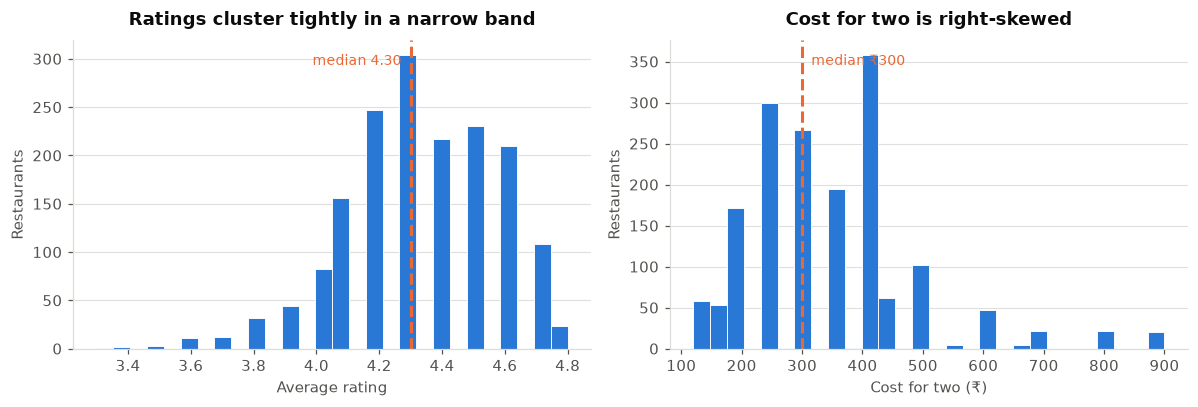

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
a = axes[0]
a.hist(rest.avg_rating.dropna(), bins=28, color=C1, edgecolor="white", linewidth=0.6)
a.axvline(rest.avg_rating.median(), color=C2, lw=2, ls="--")
a.annotate(f"median {rest.avg_rating.median():.2f}",
           (rest.avg_rating.median(), a.get_ylim()[1]*0.92), color=C2,
           fontsize=9, ha="right", xytext=(-6,0), textcoords="offset points")
finish(a, "Ratings cluster tightly in a narrow band", "Average rating", "Restaurants")

b = axes[1]
b.hist(rest.cost_w.dropna(), bins=28, color=C1, edgecolor="white", linewidth=0.6)
b.axvline(rest.cost_w.median(), color=C2, lw=2, ls="--")
b.annotate(f"median ₹{rest.cost_w.median():.0f}",
           (rest.cost_w.median(), b.get_ylim()[1]*0.92), color=C2,
           fontsize=9, ha="left", xytext=(6,0), textcoords="offset points")
finish(b, "Cost for two is right-skewed", "Cost for two (₹)", "Restaurants")
plt.tight_layout(); save(fig, "fig1_distributions"); plt.show()

saved -> report/figures/fig2_delivery_by_city.png


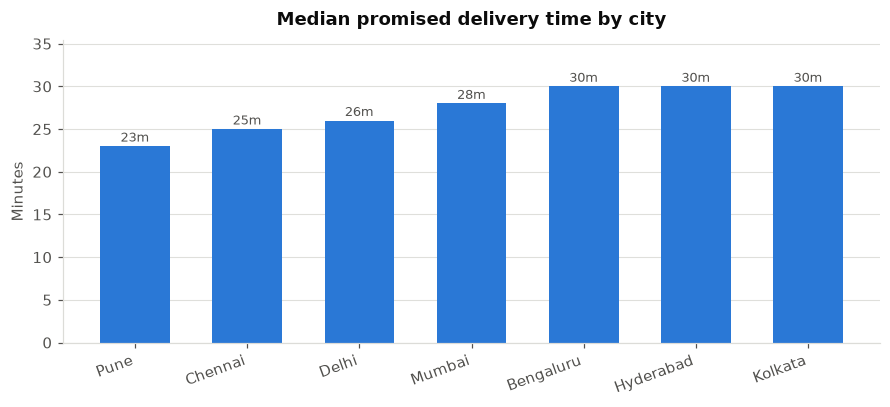

           median_delivery  restaurants
city                                   
Pune                  23.0          241
Chennai               25.0          242
Delhi                 26.0          223
Mumbai                28.0          269
Bengaluru             30.0          253
Hyderabad             30.0          231
Kolkata               30.0          227


In [11]:
order = by_city.sort_values("median_delivery").index.tolist()
fig, ax = plt.subplots(figsize=(8.2, 3.8))
vals = by_city.loc[order, "median_delivery"]
bars = ax.bar(order, vals, color=C1, width=0.62)
label_bars(ax, bars, "{:.0f}m")
finish(ax, "Median promised delivery time by city", None, "Minutes")
ax.set_ylim(0, vals.max()*1.18)
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); save(fig, "fig2_delivery_by_city"); plt.show()
print(by_city[["median_delivery","restaurants"]].loc[order].to_string())

saved -> report/figures/fig3_price_vs_rating.png


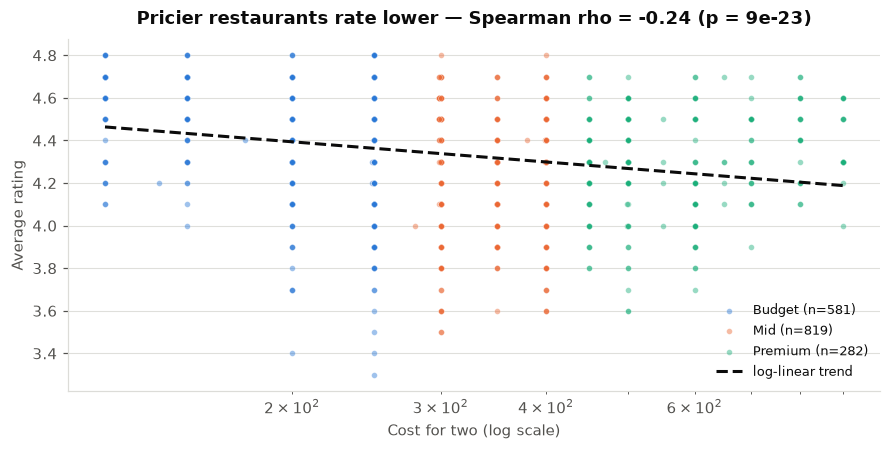

           n  mean_rating  median_cost
band                                  
Budget   581         4.41        250.0
Mid      819         4.28        350.0
Premium  282         4.31        500.0


In [12]:
# Price vs rating, split into three cost terciles (the validated all-pairs cap).
m = rest.dropna(subset=["avg_rating","cost_w"]).copy()
m["band"] = pd.qcut(m.cost_w, 3, labels=["Budget","Mid","Premium"])
fig, ax = plt.subplots(figsize=(8.2, 4.2))
for (lab, col) in zip(["Budget","Mid","Premium"], [C1, C2, C3]):
    s = m[m.band == lab]
    ax.scatter(s.cost_w, s.avg_rating, s=14, alpha=0.45, color=col,
               edgecolors="white", linewidths=0.3, label=f"{lab} (n={len(s)})")
z = np.polyfit(np.log(m.cost_w), m.avg_rating, 1)
xs = np.linspace(m.cost_w.min(), m.cost_w.max(), 100)
ax.plot(xs, np.polyval(z, np.log(xs)), color=INK, lw=2, ls="--",
        label="log-linear trend")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"₹{v:,.0f}"))
rho, pval = stats.spearmanr(m.cost_w, m.avg_rating)
direction = "higher" if z[0] > 0 else "lower"
finish(ax, f"Pricier restaurants rate {direction} — Spearman rho = {rho:.2f} (p = {pval:.1g})",
       "Cost for two (log scale)", "Average rating")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
plt.tight_layout(); save(fig, "fig3_price_vs_rating"); plt.show()
print(m.groupby("band").agg(n=("avg_rating","size"), mean_rating=("avg_rating","mean"),
                            median_cost=("cost_w","median")).round(2).to_string())

saved -> report/figures/fig4_cuisines.png


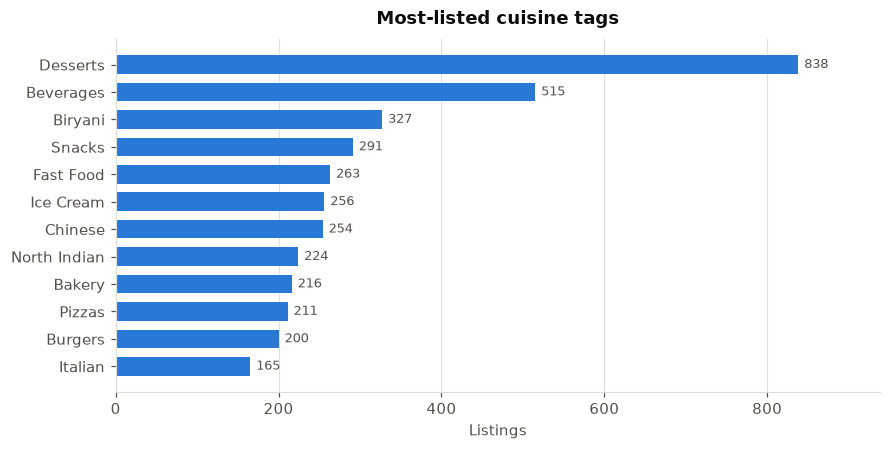

In [13]:
top_cui = (rest.cuisines.fillna("").str.split("|").explode()
             .replace("", np.nan).dropna().value_counts().head(12))
fig, ax = plt.subplots(figsize=(8.2, 4.2))
bars = ax.barh(top_cui.index[::-1], top_cui.values[::-1], color=C1, height=0.68)
for b, v in zip(bars, top_cui.values[::-1]):
    ax.annotate(f"{v}", (b.get_width(), b.get_y()+b.get_height()/2),
                xytext=(4,0), textcoords="offset points", va="center",
                fontsize=8.5, color=INK2)
finish(ax, "Most-listed cuisine tags", "Listings", None, grid_axis="x")
ax.set_xlim(0, top_cui.max()*1.12)
plt.tight_layout(); save(fig, "fig4_cuisines"); plt.show()

saved -> report/figures/fig5_offers_by_rating.png


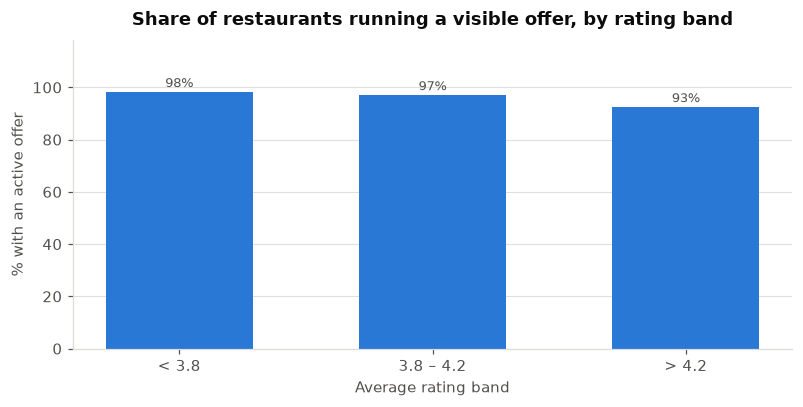

has_offer   0     1
rband              
< 3.8       1    60
3.8 – 4.2  15   514
> 4.2      81  1011

Chi-square = 15.8, dof = 2, p = 0.00038


In [14]:
# Offer prevalence by rating band — is discounting a substitute for quality?
r = rest.dropna(subset=["avg_rating"]).copy()
r["rband"] = pd.cut(r.avg_rating, [0,3.8,4.2,5.0],
                    labels=["< 3.8","3.8 – 4.2","> 4.2"])
tab = (r.groupby("rband").has_offer.agg(["mean","size"]))
fig, ax = plt.subplots(figsize=(7.4, 3.8))
bars = ax.bar(tab.index.astype(str), tab["mean"]*100, color=C1, width=0.58)
label_bars(ax, bars, "{:.0f}%")
finish(ax, "Share of restaurants running a visible offer, by rating band",
       "Average rating band", "% with an active offer")
ax.set_ylim(0, (tab["mean"].max()*100)*1.2)
plt.tight_layout(); save(fig, "fig5_offers_by_rating"); plt.show()

ct = pd.crosstab(r.rband, r.has_offer)
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(ct.to_string())
print(f"\nChi-square = {chi2:.1f}, dof = {dof}, p = {p:.3g}")

saved -> report/figures/fig6_corr.png


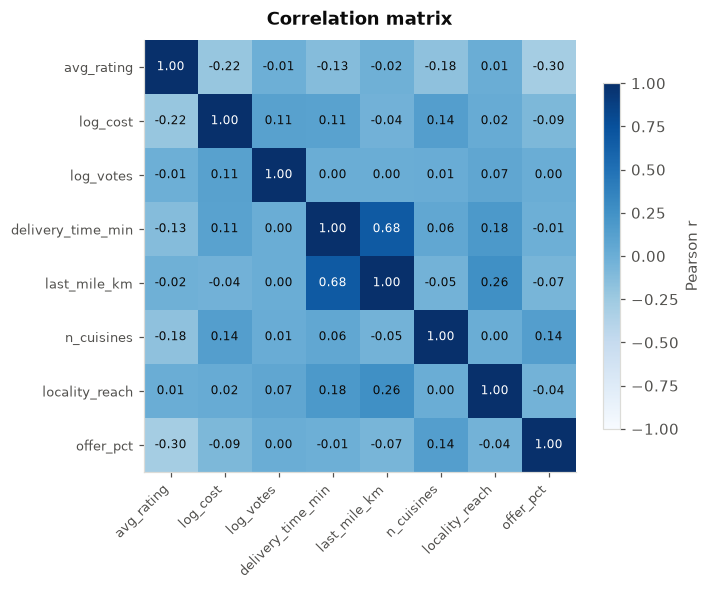

In [15]:
cols = ["avg_rating","log_cost","log_votes","delivery_time_min",
        "last_mile_km","n_cuisines","locality_reach","offer_pct"]
corr = model_df[cols].corr()
fig, ax = plt.subplots(figsize=(6.6, 5.4))
im = ax.imshow(corr, cmap=SEQ, vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=8.5)
for i in range(len(cols)):
    for j in range(len(cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 0.55 else INK)
ax.set_title("Correlation matrix", color=INK, pad=10)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
plt.tight_layout(); save(fig, "fig6_corr"); plt.show()

## 4. Analytics Method and Implementation

Four methods, each chosen for a specific question in the syllabus toolkit:

| Question | Method | Why this method |
|---|---|---|
| Which listing attributes drive rating? | **Multiple linear regression (OLS)** | Coefficients are directly interpretable as business levers; supports significance testing and diagnostics |
| Can rating be predicted better non-linearly? | **Random Forest / Gradient Boosting** | Captures interactions the OLS misses; permutation importance gives an honest driver ranking |
| Which restaurants are *highly rated*? | **Logistic regression** | A classification framing management can act on, with ROC-AUC as a threshold-free metric |
| How do restaurants position themselves? | **K-Means clustering** | Unsupervised segmentation on price–quality–speed; k chosen by elbow + silhouette |

### 4.1 Multiple linear regression — drivers of rating

In [16]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

feat = ["log_cost","log_votes","delivery_time_min","last_mile_km",
        "n_cuisines","locality_reach","is_chain","has_offer","offer_pct"]
X = model_df[feat].copy()
X = pd.concat([X, pd.get_dummies(model_df.city, prefix="city", drop_first=True)], axis=1)
X = X.astype(float)
y = model_df.avg_rating.astype(float)

Xc = sm.add_constant(X)
ols = sm.OLS(y, Xc).fit()
print(ols.summary().tables[0])
print(ols.summary().tables[1])

                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     39.94
Date:                Sat, 19 Sep 2026   Prob (F-statistic):          9.82e-100
Time:                        21:47:34   Log-Likelihood:                 268.70
No. Observations:                1667   AIC:                            -505.4
Df Residuals:                    1651   BIC:                            -418.7
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 5.3135      0.08

In [17]:
# VIF is only meaningful on a design matrix that INCLUDES the intercept column;
# computing it on the bare feature matrix inflates every value.
vif = pd.DataFrame({
    "feature": Xc.columns,
    "VIF": [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
}).query("feature != 'const'").sort_values("VIF", ascending=False).round(2)
print("Multicollinearity check (VIF > 5 is a concern):")
print(vif.head(10).to_string(index=False))

bp = sm.stats.diagnostic.het_breuschpagan(ols.resid, Xc)
print(f"\nBreusch-Pagan p = {bp[1]:.3g}  (low p => heteroskedastic; use robust SEs)")
ols_rob = sm.OLS(y, Xc).fit(cov_type="HC3")
print(f"R-squared = {ols.rsquared:.3f} | Adj. R-squared = {ols.rsquared_adj:.3f}")

Multicollinearity check (VIF > 5 is a concern):
          feature  VIF
delivery_time_min 2.67
     last_mile_km 2.40
        city_Pune 2.08
     city_Chennai 2.00
       city_Delhi 1.84
      city_Mumbai 1.82
   city_Hyderabad 1.78
     city_Kolkata 1.76
         is_chain 1.18
        has_offer 1.13

Breusch-Pagan p = 1.79e-11  (low p => heteroskedastic; use robust SEs)
R-squared = 0.266 | Adj. R-squared = 0.260


saved -> report/figures/fig7_ols_diagnostics.png


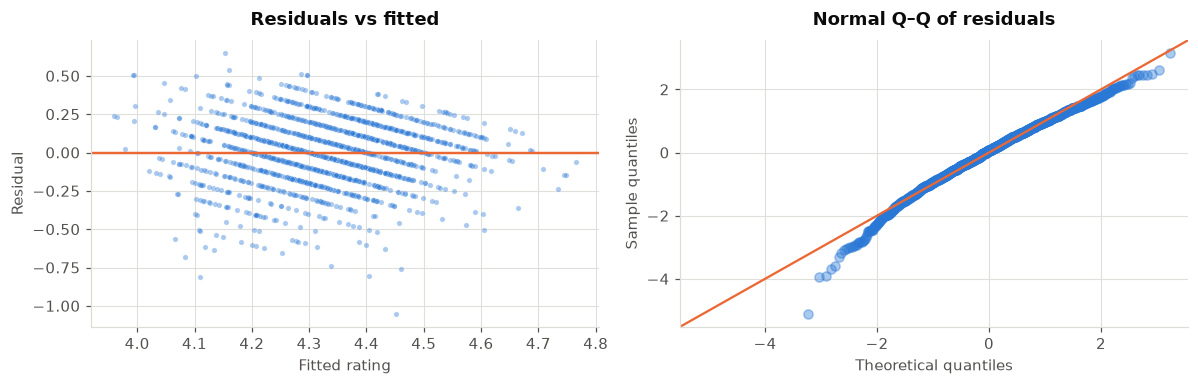

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].scatter(ols.fittedvalues, ols.resid, s=12, alpha=0.4, color=C1,
                edgecolors="white", linewidths=0.3)
axes[0].axhline(0, color=C2, lw=1.6)
finish(axes[0], "Residuals vs fitted", "Fitted rating", "Residual", grid_axis="both")
sm.qqplot(ols.resid, line="45", fit=True, ax=axes[1],
          markerfacecolor=C1, markeredgecolor=C1, alpha=0.4)
axes[1].get_lines()[1].set_color(C2)
finish(axes[1], "Normal Q–Q of residuals", "Theoretical quantiles", "Sample quantiles", grid_axis="both")
plt.tight_layout(); save(fig, "fig7_ols_diagnostics"); plt.show()

In [19]:
sig = (pd.DataFrame({"coef": ols_rob.params, "p": ols_rob.pvalues})
         .drop("const").assign(abs_coef=lambda d: d.coef.abs())
         .sort_values("abs_coef", ascending=False).round(4))
sig["significant"] = np.where(sig.p < 0.05, "yes", "no")
print("Robust (HC3) coefficients, largest effect first:")
sig[["coef","p","significant"]]

Robust (HC3) coefficients, largest effect first:


,coef,p,significant
city_Kolkata,0.1323,0.0000,yes
city_Pune,-0.1163,0.0000,yes
log_cost,-0.1137,0.0000,yes
city_Hyderabad,-0.0935,0.0000,yes
has_offer,-0.0931,0.0001,yes
city_Mumbai,0.0471,0.0073,yes
city_Chennai,-0.0367,0.0569,no
locality_reach,0.0263,0.0779,no
last_mile_km,0.0149,0.0010,yes
n_cuisines,-0.0115,0.0000,yes


### 4.2 Tree ensembles — can a non-linear model do better?

In [20]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                           random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}
rows = []
fitted = {}
cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
for name, mdl in models.items():
    mdl.fit(Xtr, ytr)
    fitted[name] = mdl
    pred = mdl.predict(Xte)
    rows.append({
        "Model": name,
        "CV R² (5-fold)": cross_val_score(mdl, X, y, cv=cv, scoring="r2").mean(),
        "Test R²": r2_score(yte, pred),
        "Test RMSE": mean_squared_error(yte, pred) ** 0.5,
        "Test MAE": mean_absolute_error(yte, pred),
    })
perf = pd.DataFrame(rows).round(3)
perf

,Model,CV R² (5-fold),Test R²,Test RMSE,Test MAE
0,Linear Regression,0.251,0.261,0.203,0.163
1,Random Forest,0.469,0.487,0.169,0.131
2,Gradient Boosting,0.442,0.465,0.173,0.135


Best regressor: Random Forest


saved -> report/figures/fig8_importance.png


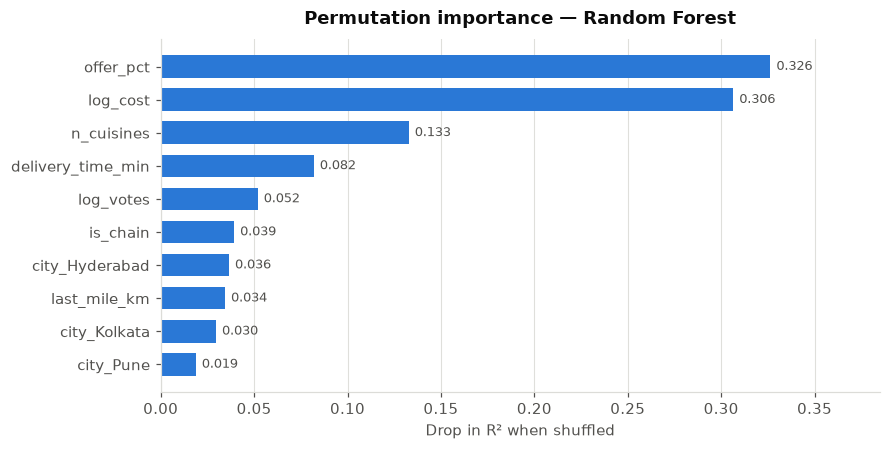

offer_pct            0.3263
log_cost             0.3064
n_cuisines           0.1327
delivery_time_min    0.0819
log_votes            0.0519
is_chain             0.0392
city_Hyderabad       0.0365
last_mile_km         0.0344
city_Kolkata         0.0296
city_Pune            0.0187


In [21]:
best_name = perf.sort_values("Test R²", ascending=False).Model.iloc[0]
best = fitted[best_name]
print("Best regressor:", best_name)

pi = permutation_importance(best, Xte, yte, n_repeats=20,
                            random_state=RANDOM_STATE, n_jobs=-1)
imp = (pd.Series(pi.importances_mean, index=X.columns)
         .sort_values(ascending=False).head(10))
fig, ax = plt.subplots(figsize=(8.2, 4.2))
bars = ax.barh(imp.index[::-1], imp.values[::-1], color=C1, height=0.68)
for b, v in zip(bars, imp.values[::-1]):
    ax.annotate(f"{v:.3f}", (b.get_width(), b.get_y()+b.get_height()/2),
                xytext=(4,0), textcoords="offset points", va="center",
                fontsize=8.5, color=INK2)
finish(ax, f"Permutation importance — {best_name}", "Drop in R² when shuffled",
       None, grid_axis="x")
ax.set_xlim(0, imp.max()*1.18)
plt.tight_layout(); save(fig, "fig8_importance"); plt.show()
print(imp.round(4).to_string())

### 4.3 Logistic regression — what makes a restaurant *highly rated*?

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                             confusion_matrix)

THRESH = 4.2
yb = (model_df.avg_rating >= THRESH).astype(int)
Xtr, Xte, ytr, yte = train_test_split(X, yb, test_size=0.25,
                                      random_state=RANDOM_STATE, stratify=yb)
print(f"Positive class: rating >= {THRESH}  ({yb.mean():.1%} of the sample)")
print("Classes are heavily imbalanced, so an unweighted model can score well on "
      "accuracy while barely detecting the minority class. Both are fitted below.")
print()

clf_plain = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
clf_plain.fit(Xtr, ytr)
p_plain = clf_plain.predict_proba(Xte)[:, 1]
rec_plain = classification_report(yte, (p_plain >= 0.5).astype(int),
                                  output_dict=True)["0"]["recall"]

clf = make_pipeline(StandardScaler(),
                    LogisticRegression(max_iter=2000, class_weight="balanced"))
clf.fit(Xtr, ytr)
proba = clf.predict_proba(Xte)[:, 1]
pred = (proba >= 0.5).astype(int)
rec_bal = classification_report(yte, pred, output_dict=True)["0"]["recall"]

print(f"Unweighted  ROC-AUC = {roc_auc_score(yte, p_plain):.3f} | "
      f"minority-class recall = {rec_plain:.2f}")
print(f"Balanced    ROC-AUC = {roc_auc_score(yte, proba):.3f} | "
      f"minority-class recall = {rec_bal:.2f}")
print()
print("Class-weighted model:")
print(classification_report(yte, pred, target_names=["Not high", "Highly rated"]))
print("Confusion matrix:\n", confusion_matrix(yte, pred))

Positive class: rating >= 4.2  (79.5% of the sample)
Classes are heavily imbalanced, so an unweighted model can score well on accuracy while barely detecting the minority class. Both are fitted below.

Unweighted  ROC-AUC = 0.728 | minority-class recall = 0.14
Balanced    ROC-AUC = 0.726 | minority-class recall = 0.59

Class-weighted model:
              precision    recall  f1-score   support

    Not high       0.34      0.59      0.43        85
Highly rated       0.87      0.71      0.78       332

    accuracy                           0.68       417
   macro avg       0.61      0.65      0.61       417
weighted avg       0.76      0.68      0.71       417

Confusion matrix:
 [[ 50  35]
 [ 97 235]]


saved -> report/figures/fig9_roc.png


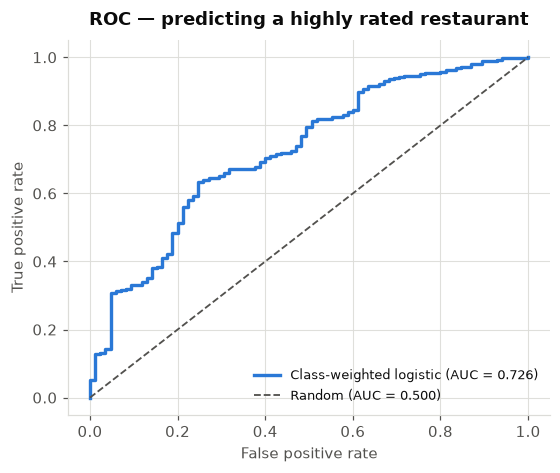

Odds ratios per 1 SD increase (>1 raises the odds of a high rating):
city_Kolkata      1.592
city_Mumbai       1.340
last_mile_km      1.271
locality_reach    1.196
log_votes         1.151
city_Delhi        1.132
city_Chennai      0.985
is_chain          0.973


In [23]:
fpr, tpr, _ = roc_curve(yte, proba)
auc = roc_auc_score(yte, proba)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.plot(fpr, tpr, color=C1, lw=2.2, label=f"Class-weighted logistic (AUC = {auc:.3f})")
ax.plot([0,1], [0,1], color=INK2, lw=1.2, ls="--", label="Random (AUC = 0.500)")
finish(ax, "ROC — predicting a highly rated restaurant",
       "False positive rate", "True positive rate", grid_axis="both")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
plt.tight_layout(); save(fig, "fig9_roc"); plt.show()

odds = (pd.Series(clf[-1].coef_[0], index=X.columns)
          .pipe(np.exp).sort_values(ascending=False))
print("Odds ratios per 1 SD increase (>1 raises the odds of a high rating):")
print(odds.head(8).round(3).to_string())

### 4.4 K-Means — price–quality–speed segmentation

saved -> report/figures/fig10_k_selection.png


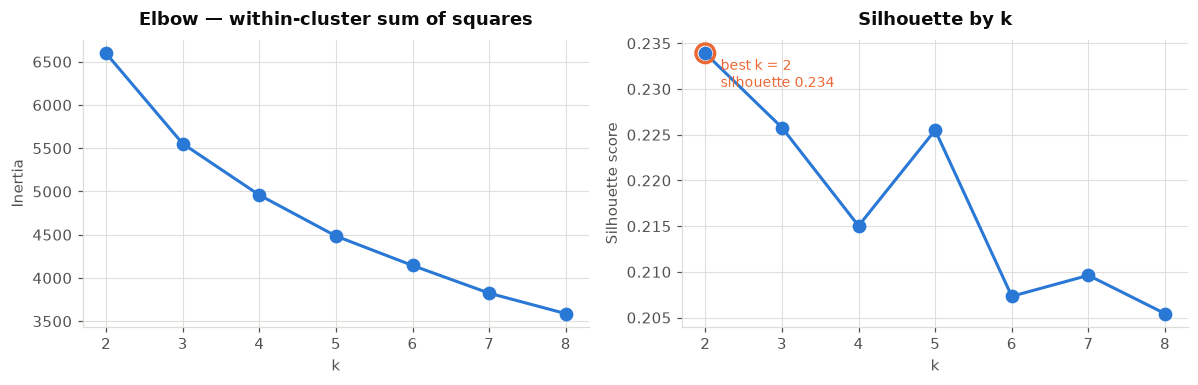

silhouette by k: {2: np.float64(0.234), 3: np.float64(0.226), 4: np.float64(0.215), 5: np.float64(0.225), 6: np.float64(0.207), 7: np.float64(0.21), 8: np.float64(0.205)}


In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

seg_feats = ["log_cost","avg_rating","delivery_time_min","log_votes","offer_pct"]
S = model_df[seg_feats].dropna()
Z = StandardScaler().fit_transform(S)

ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Z, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(list(ks), inertia, marker="o", color=C1, lw=2, ms=8)
finish(axes[0], "Elbow — within-cluster sum of squares", "k", "Inertia", grid_axis="both")
axes[1].plot(list(ks), sil, marker="o", color=C1, lw=2, ms=8)
best_k = list(ks)[int(np.argmax(sil))]
axes[1].scatter([best_k], [max(sil)], s=150, facecolor="none", edgecolor=C2, lw=2.2, zorder=5)
axes[1].annotate(f"best k = {best_k}\nsilhouette {max(sil):.3f}", (best_k, max(sil)),
                 xytext=(10, -22), textcoords="offset points", fontsize=9, color=C2)
finish(axes[1], "Silhouette by k", "k", "Silhouette score", grid_axis="both")
plt.tight_layout(); save(fig, "fig10_k_selection"); plt.show()
print("silhouette by k:", dict(zip(ks, np.round(sil, 3))))

In [25]:
K = 4 if 4 in ks else best_k
km = KMeans(n_clusters=K, n_init=25, random_state=RANDOM_STATE).fit(Z)
S = S.assign(segment=km.labels_)
seg = model_df.loc[S.index].assign(segment=km.labels_)

profile = (seg.groupby("segment")
             .agg(n=("restaurant_id","size"),
                  avg_rating=("avg_rating","mean"),
                  cost_for_two=("cost_w","median"),
                  delivery_min=("delivery_time_min","median"),
                  n_ratings=("n_ratings","median"),
                  offer_pct=("offer_pct","mean"),
                  pct_chain=("is_chain","mean"))
             .round(2))
profile["pct_chain"] = (profile.pct_chain*100).round(0)
print(f"K = {K}, silhouette = {silhouette_score(Z, km.labels_):.3f}\n")
profile

K = 4, silhouette = 0.215



,n,avg_rating,cost_for_two,delivery_min,n_ratings,offer_pct,pct_chain
segment,,,,,,,
0,267,4.22,400.0,35.0,1800.0,4.63,62.0
1,404,4.55,200.0,25.0,2200.0,15.42,89.0
2,442,4.38,400.0,26.0,16000.0,1.32,80.0
3,554,4.19,300.0,28.0,6200.0,62.92,86.0


In [26]:
# Name each segment from its own profile rather than by hand.
med_cost, med_rate = profile.cost_for_two.median(), profile.avg_rating.median()
names = {}
for s, row in profile.iterrows():
    price = "Premium" if row.cost_for_two >= med_cost else "Value"
    qual  = "performer" if row.avg_rating >= med_rate else "laggard"
    names[s] = f"{price} {qual}"
# disambiguate duplicates by discount intensity
seen = {}
for s in list(names):
    if list(names.values()).count(names[s]) > 1:
        names[s] += " (high discount)" if profile.loc[s,"offer_pct"] >= profile.offer_pct.median() else " (low discount)"
profile.insert(0, "segment_name", [names[s] for s in profile.index])
seg["segment_name"] = seg.segment.map(names)
profile

,segment_name,n,avg_rating,cost_for_two,delivery_min,n_ratings,offer_pct,pct_chain
segment,,,,,,,,
0,Premium laggard,267,4.22,400.0,35.0,1800.0,4.63,62.0
1,Value performer,404,4.55,200.0,25.0,2200.0,15.42,89.0
2,Premium performer,442,4.38,400.0,26.0,16000.0,1.32,80.0
3,Value laggard,554,4.19,300.0,28.0,6200.0,62.92,86.0


saved -> report/figures/fig11_segments.png


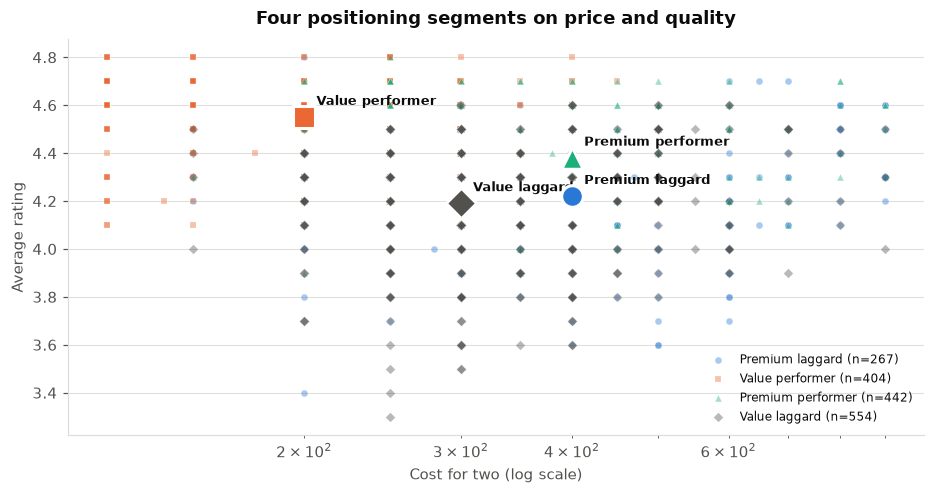

In [27]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
# 4 segments exceed the 3-slot all-pairs cap, so segments are also separated by
# marker shape and each centroid is directly labelled.
palette = [C1, C2, C3, INK2]
markers = ["o", "s", "^", "D"]
for i, s in enumerate(sorted(seg.segment.unique())):
    d = seg[seg.segment == s]
    ax.scatter(d.cost_w, d.avg_rating, s=20, alpha=0.4, color=palette[i % 4],
               marker=markers[i % 4], edgecolors="white", linewidths=0.3,
               label=f"{names[s]} (n={len(d)})")
for i, s in enumerate(sorted(seg.segment.unique())):
    cx, cy = profile.loc[s,"cost_for_two"], profile.loc[s,"avg_rating"]
    ax.scatter([cx],[cy], s=200, marker=markers[i % 4], color=palette[i % 4],
               edgecolors="white", linewidths=2, zorder=5)
    ax.annotate(names[s], (cx, cy), xytext=(8, 8), textcoords="offset points",
                fontsize=8.5, color=INK, weight="bold")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"₹{v:,.0f}"))
finish(ax, "Four positioning segments on price and quality",
       "Cost for two (log scale)", "Average rating")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout(); save(fig, "fig11_segments"); plt.show()

In [28]:
mix = pd.crosstab(seg.city, seg.segment_name, normalize="index").mul(100).round(1)
print("Segment mix by city (% of that city's rated restaurants):")
mix

Segment mix by city (% of that city's rated restaurants):


segment_name,Premium laggard,Premium performer,Value laggard,Value performer
city,,,,
Bengaluru,19.4,31.3,25.8,23.4
Chennai,10.4,37.8,29.5,22.4
Delhi,11.9,25.7,37.2,25.2
Hyderabad,21.3,21.7,38.3,18.7
Kolkata,23.3,17.8,31.5,27.4
Mumbai,16.2,21.1,32.3,30.5
Pune,10.0,29.5,39.0,21.6


### 4.5 Predicting delivery time — the operations model

Objective 1 of the proposal asks what drives delivery performance, and objective 4
asks for a delivery-time predictor. We model the promised delivery time from
distance, restaurant characteristics and city, comparing a linear baseline against
two ensembles on a held-out test set.

In [29]:
dt = model_df.dropna(subset=["delivery_time_min","last_mile_km"]).copy()

dfeat = ["last_mile_km","log_cost","avg_rating","log_votes",
         "n_cuisines","is_chain","has_offer"]
Xd = pd.concat([dt[dfeat],
                pd.get_dummies(dt.city, prefix="city", drop_first=True)],
               axis=1).astype(float)
yd = dt.delivery_time_min.astype(float)

Xdtr, Xdte, ydtr, ydte = train_test_split(Xd, yd, test_size=0.25,
                                          random_state=RANDOM_STATE)
drows, dfit = [], {}
for name, mdl in {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                               random_state=RANDOM_STATE, n_jobs=-1),
        "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    }.items():
    mdl.fit(Xdtr, ydtr); dfit[name] = mdl
    pr = mdl.predict(Xdte)
    drows.append({"Model": name,
                  "CV R² (5-fold)": cross_val_score(mdl, Xd, yd, cv=cv, scoring="r2").mean(),
                  "Test R²": r2_score(ydte, pr),
                  "Test RMSE (min)": mean_squared_error(ydte, pr) ** 0.5,
                  "Test MAE (min)": mean_absolute_error(ydte, pr)})
dperf = pd.DataFrame(drows).round(3)
dperf

,Model,CV R² (5-fold),Test R²,Test RMSE (min),Test MAE (min)
0,Linear Regression,0.633,0.613,5.499,4.181
1,Random Forest,0.694,0.643,5.279,3.931
2,Gradient Boosting,0.692,0.651,5.217,3.939


In [30]:
# Interpretable companion: how many minutes does each extra kilometre cost?
Xd_ols = sm.add_constant(Xd)
dm = sm.OLS(yd, Xd_ols).fit()
print(f"OLS R-squared = {dm.rsquared:.3f}")
print(f"Each extra km of last-mile distance adds "
      f"{dm.params['last_mile_km']:.2f} min (p = {dm.pvalues['last_mile_km']:.3g})")
print(dm.summary().tables[1])

OLS R-squared = 0.640
Each extra km of last-mile distance adds 3.43 min (p = 2.07e-272)
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             38.8718      3.941      9.863      0.000      31.142      46.602
last_mile_km       3.4331      0.080     43.073      0.000       3.277       3.589
log_cost           2.1163      0.356      5.946      0.000       1.418       2.814
avg_rating        -5.7231      0.623     -9.189      0.000      -6.945      -4.502
log_votes         -0.0243      0.094     -0.260      0.795      -0.208       0.159
n_cuisines         0.2315      0.073      3.188      0.001       0.089       0.374
is_chain          -1.1784      0.379     -3.113      0.002      -1.921      -0.436
has_offer         -0.8887      0.623     -1.426      0.154      -2.111       0.334
city_Chennai      -7.7618      0.519    -14.964      0.000      -8.779      -6.744

saved -> report/figures/fig12_delivery_model.png


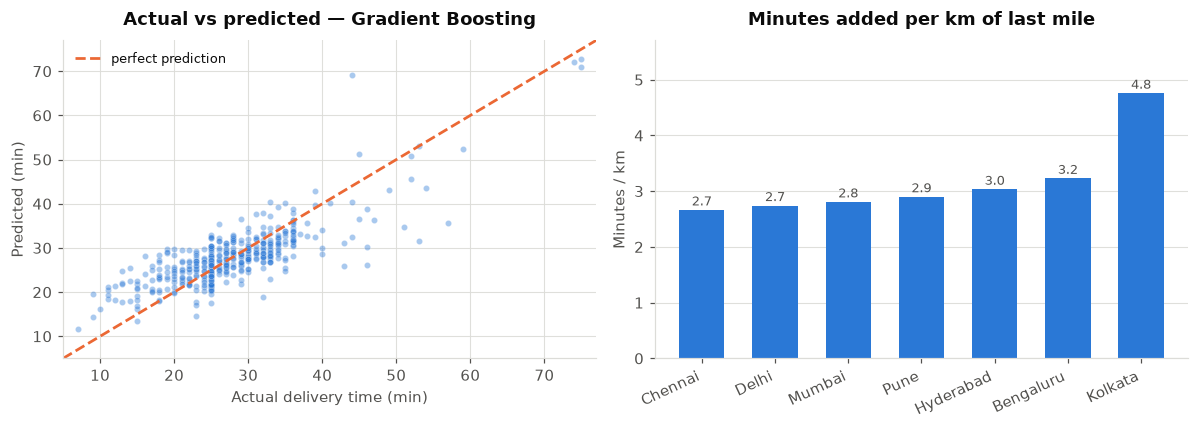

city
Chennai      2.66
Delhi        2.74
Mumbai       2.81
Pune         2.90
Hyderabad    3.03
Bengaluru    3.23
Kolkata      4.76


In [31]:
d_best_name = dperf.sort_values("Test R²", ascending=False).Model.iloc[0]
d_best = dfit[d_best_name]
dpred = d_best.predict(Xdte)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
a = axes[0]
a.scatter(ydte, dpred, s=16, alpha=0.4, color=C1, edgecolors="white", linewidths=0.3)
lims = [min(ydte.min(), dpred.min()) - 2, max(ydte.max(), dpred.max()) + 2]
a.plot(lims, lims, color=C2, lw=1.8, ls="--", label="perfect prediction")
a.set_xlim(lims); a.set_ylim(lims)
finish(a, f"Actual vs predicted — {d_best_name}", "Actual delivery time (min)",
       "Predicted (min)", grid_axis="both")
a.legend(frameon=False, fontsize=8.5, loc="upper left")

# Minutes per km by city, from city-specific simple fits
b = axes[1]
slopes = (dt.groupby("city")
            .apply(lambda g: np.polyfit(g.last_mile_km, g.delivery_time_min, 1)[0])
            .sort_values())
bars = b.bar(slopes.index, slopes.values, color=C1, width=0.62)
label_bars(b, bars, "{:.1f}")
finish(b, "Minutes added per km of last mile", None, "Minutes / km")
b.set_ylim(0, slopes.max()*1.2)
b.tick_params(axis="x", rotation=25)
for t in b.get_xticklabels(): t.set_ha("right")
plt.tight_layout(); save(fig, "fig12_delivery_model"); plt.show()
print(slopes.round(2).to_string())

saved -> report/figures/fig13_delivery_importance.png


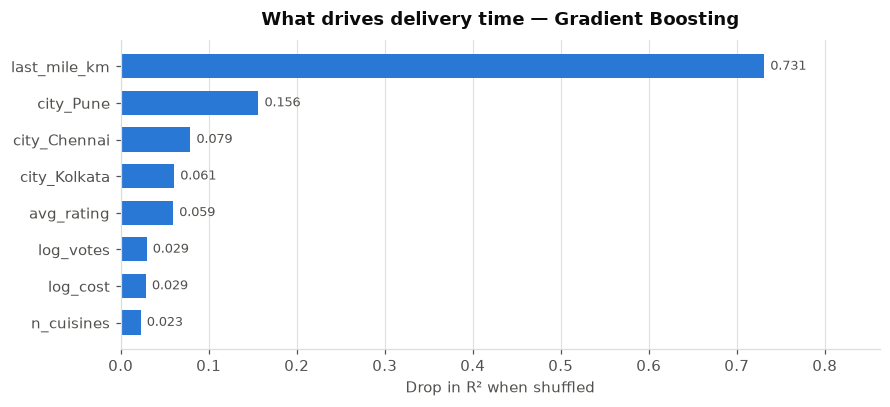

In [32]:
dpi = permutation_importance(d_best, Xdte, ydte, n_repeats=20,
                             random_state=RANDOM_STATE, n_jobs=-1)
dimp = (pd.Series(dpi.importances_mean, index=Xd.columns)
          .sort_values(ascending=False).head(8))
fig, ax = plt.subplots(figsize=(8.2, 3.8))
bars = ax.barh(dimp.index[::-1], dimp.values[::-1], color=C1, height=0.66)
for bb, v in zip(bars, dimp.values[::-1]):
    ax.annotate(f"{v:.3f}", (bb.get_width(), bb.get_y()+bb.get_height()/2),
                xytext=(4,0), textcoords="offset points", va="center",
                fontsize=8.5, color=INK2)
finish(ax, f"What drives delivery time — {d_best_name}", "Drop in R² when shuffled",
       None, grid_axis="x")
ax.set_xlim(0, dimp.max()*1.18)
plt.tight_layout(); save(fig, "fig13_delivery_importance"); plt.show()

### 4.6 Competitor benchmarking

Objective 3 asks for a competitor comparison on delivery time, pricing, rating and
promotions. Outlets are rolled up to the **brand** (`chain_parent_id`) so that
multi-outlet operators are compared as competitors rather than as individual
listings.

In [33]:
brands = (rest[rest.chain_outlets >= 5]
            .groupby(["chain_parent_id","name"], as_index=False)
            .agg(outlets=("restaurant_id","size"),
                 cities=("city","nunique"),
                 avg_rating=("avg_rating","mean"),
                 median_cost=("cost_w","median"),
                 median_delivery=("delivery_time_min","median"),
                 pct_offer=("has_offer","mean"),
                 median_votes=("n_ratings","median")))
brands = (brands.sort_values("outlets", ascending=False)
                .drop_duplicates("name")
                .head(15).round(2))
brands["pct_offer"] = (brands.pct_offer*100).round(0)
print("Top 15 multi-outlet brands in the sample:")
brands.drop(columns="chain_parent_id").reset_index(drop=True)

Top 15 multi-outlet brands in the sample:


,name,outlets,cities,avg_rating,median_cost,median_delivery,pct_offer,median_votes
0,Baskin Robbins - Ice Cream Desserts,59,7,4.52,250.0,24.0,100.0,1700.0
1,KFC,58,7,4.14,400.0,26.0,100.0,14000.0
2,McDonald's,55,7,4.34,400.0,26.0,100.0,23000.0
3,Subway,51,7,4.23,350.0,24.0,88.0,16000.0
4,Domino's Pizza,51,7,4.35,400.0,25.0,100.0,16000.0
5,The Belgian Waffle Co.,47,7,4.53,200.0,28.0,98.0,3000.0
6,Pizza Hut,46,6,4.18,350.0,29.5,100.0,9850.0
7,Theobroma,44,5,4.49,400.0,19.0,100.0,8450.0
8,Burger King,42,7,4.20,350.0,27.0,100.0,21500.0
9,NIC Ice Creams,35,6,4.65,120.0,23.0,100.0,9800.0


saved -> report/figures/fig14_benchmark.png


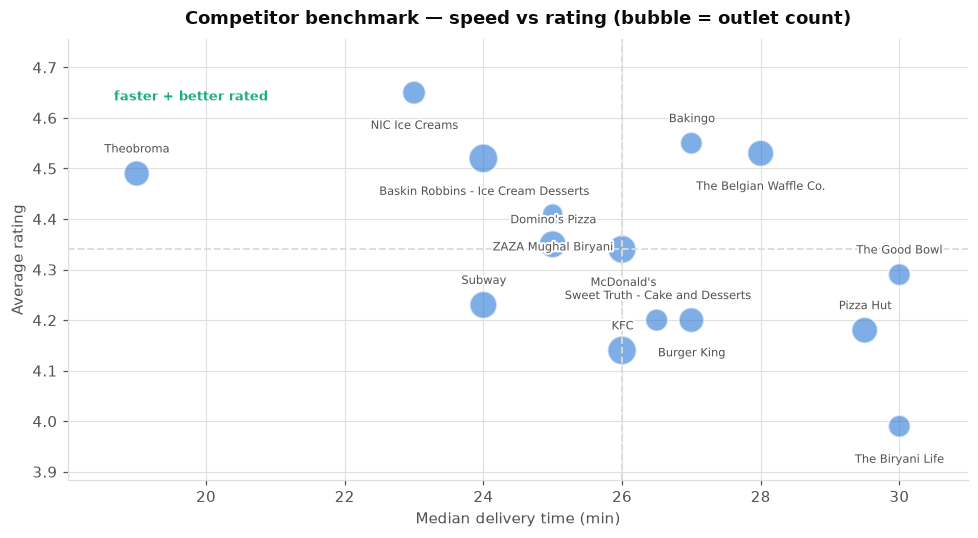

In [34]:
b = brands.sort_values("avg_rating")
fig, ax = plt.subplots(figsize=(9.0, 5.0))
sizes = (b.outlets / b.outlets.max() * 320) + 40
sc = ax.scatter(b.median_delivery, b.avg_rating, s=sizes, alpha=0.6,
                color=C1, edgecolors="white", linewidths=1.2)
# Stagger labels above/below along the x-order so they do not collide.
lab = b.sort_values("median_delivery").reset_index(drop=True)
for i, r in lab.iterrows():
    above = (i % 2 == 0)
    ax.annotate(r["name"], (r.median_delivery, r.avg_rating),
                xytext=(0, 12 if above else -18), textcoords="offset points",
                ha="center", va="bottom" if above else "top",
                fontsize=7.5, color=INK2,
                path_effects=[pe.withStroke(linewidth=2.6, foreground="white")])
ax.axvline(b.median_delivery.median(), color=GRID, lw=1.2, ls="--")
ax.axhline(b.avg_rating.median(), color=GRID, lw=1.2, ls="--")
ax.annotate("faster + better rated", (ax.get_xlim()[0], ax.get_ylim()[1]),
            xytext=(10, -16), textcoords="offset points", fontsize=8.5,
            color=C3, weight="bold")
finish(ax, "Competitor benchmark — speed vs rating (bubble = outlet count)",
       "Median delivery time (min)", "Average rating", grid_axis="both")
ax.margins(x=0.09, y=0.16)
plt.tight_layout(); save(fig, "fig14_benchmark"); plt.show()

## 6. Results Summary

In [35]:
summary = pd.DataFrame([
    ["Restaurant-locality observations scraped", f"{len(raw):,}"],
    ["Unique restaurants after de-duplication", f"{len(rest):,}"],
    ["Cities / localities covered", f"{rest.city.nunique()} / {raw.probe_locality.nunique()}"],
    ["Restaurants carrying a rating", f"{rest.avg_rating.notna().mean():.1%}"],
    ["Median cost for two", f"₹{rest.cost_w.median():.0f}"],
    ["Median promised delivery time", f"{rest.delivery_time_min.median():.0f} min"],
    ["Restaurants running a visible offer", f"{rest.has_offer.mean():.1%}"],
    ["OLS adjusted R² (rating model)", f"{ols.rsquared_adj:.3f}"],
    [f"Best regressor ({best_name}) test R²", f"{perf.set_index('Model').loc[best_name,'Test R²']:.3f}"],
    ["Logistic ROC-AUC (rating ≥ 4.2)", f"{auc:.3f}"],
    [f"K-Means segments (k={K}) silhouette", f"{silhouette_score(Z, km.labels_):.3f}"],
    [f"Best delivery-time model ({d_best_name}) test R²",
     f"{dperf.set_index('Model').loc[d_best_name,'Test R²']:.3f}"],
    ["Delivery-time test MAE",
     f"{dperf.set_index('Model').loc[d_best_name,'Test MAE (min)']:.2f} min"],
    ["Minutes added per extra km of last mile", f"{dm.params['last_mile_km']:.2f}"],
    ["Multi-outlet brands benchmarked", f"{len(brands)}"],
], columns=["Metric", "Value"])
summary

,Metric,Value
0,Restaurant-locality observations scraped,"1,831"
1,Unique restaurants after de-duplication,"1,686"
2,Cities / localities covered,7 / 70
3,Restaurants carrying a rating,99.8%
4,Median cost for two,₹300
5,Median promised delivery time,27 min
6,Restaurants running a visible offer,94.1%
7,OLS adjusted R² (rating model),0.260
8,Best regressor (Random Forest) test R²,0.487
9,Logistic ROC-AUC (rating ≥ 4.2),0.726


In [36]:
perf.to_csv(ROOT / "report" / "model_performance_rating.csv", index=False)
dperf.to_csv(ROOT / "report" / "model_performance_delivery.csv", index=False)
brands.drop(columns="chain_parent_id").to_csv(ROOT / "report" / "competitor_benchmark.csv", index=False)
profile.to_csv(ROOT / "report" / "segment_profiles.csv")
summary.to_csv(ROOT / "report" / "summary_metrics.csv", index=False)
by_city.to_csv(ROOT / "report" / "city_profile.csv")
print("Exported result tables to report/")
print("\nFinal check — files written:")
for p in sorted((ROOT / 'report').glob('*.csv')): print(" ", p.name)
print(f"  figures: {len(list(FIG.glob('*.png')))} png")

Exported result tables to report/

Final check — files written:
  city_profile.csv
  competitor_benchmark.csv
  model_performance_delivery.csv
  model_performance_rating.csv
  segment_profiles.csv
  summary_metrics.csv
  figures: 14 png


## 7. Reproducing this notebook

```bash
python3 scripts/scrape_swiggy.py     # re-collects data/swiggy_raw.csv from Swiggy
jupyter nbconvert --execute --to notebook --inplace analysis.ipynb
```

Listings change continuously, so a fresh scrape will not reproduce these numbers
exactly — `data/swiggy_raw.csv` is the frozen snapshot this report is built on.